# Binary SwinV2-Base Dermoscope-Only — 5-Fold Cross-Validation (Full Fine-Tune)

K-Fold CV version of the full fine-tuning experiment with **SwinV2-Base** (Swin Transformer V2). Instead of a single train/val split, we train 5 independent models and average their results for more robust performance estimates (mean ± std).

**Protocol:** Hold out 10% test set → 5-fold CV on remaining 90% → each fold: warmup (frozen, 5 epochs) + full fine-tune entire backbone (up to 30 epochs) → evaluate all folds on shared test set → ensemble by averaging probabilities.

**Model:** `microsoft/swinv2-base-patch4-window8-256` (256×256 input)

**Binary labels:**
| Original Class | Binary Label |
|---|---|
| Melanoma | **Malignant** (1) |
| BCC | **Malignant** (1) |
| SCC | **Malignant** (1) |
| Actinic Keratosis | **Malignant** (1) |
| Malignant_Other | **Malignant** (1) |
| Melanocytic_Nevus | **Benign** (0) |
| Seborrheic_Keratosis | **Benign** (0) |
| Dermatofibroma | **Benign** (0) |
| Hemangioma | **Benign** (0) |
| Fibrous_Papule | **Benign** (0) |
| Other_Benign | **Benign** (0) |

## 1. Setup & Imports

In [39]:
import os
import copy
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch._dynamo

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, precision_recall_fscore_support, fbeta_score
)

from transformers import Swinv2ForImageClassification

from utils import (
    BinaryDermoscopeSkinDataset,
    get_transforms,
    BINARY_MAP,
    CLASS_NAMES,
    BinaryFocalLossWithSmoothing,
    mixup_data,
    mixup_criterion,
    find_optimal_threshold,
    compute_metrics,
    MIN_SENSITIVITY_TARGET,
)

In [42]:
# -- Configuration --
IMAGES_DIR = "../DataCleaning/Images"
MANIFEST_PATH = "../DataCleaning/instances.csv"
BATCH_SIZE = 8  # Increased; reduce if you hit OOM
SEED = 42
K_FOLDS = 5

TRAIN_THRESHOLD = 0.5

# Training config
WARMUP_EPOCHS = 5
FT_EPOCHS = 30
PATIENCE = 8
MIXUP_ALPHA = 0.15

LR_BACKBONE = 2e-5
LR_HEAD = 1e-4
LABEL_SMOOTHING = 0.05

# SwinV2-Base uses 256x256 input
IMAGE_SIZE = 256
RESIZE_SIZE = 288

# Data loading optimizations
NUM_WORKERS = 0 if os.name == "nt" else min(os.cpu_count() or 8, 12)
PREFETCH_FACTOR = 2 if NUM_WORKERS > 0 else None

# Runtime optimizations
USE_TORCH_COMPILE = True

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()
torch.backends.cudnn.benchmark = True
torch._dynamo.config.suppress_errors = True

print(f"Using: {DEVICE}")
print(f"Mixed precision: {USE_AMP}")
print(f"PyTorch: {torch.__version__}")
print(f"Workers: {NUM_WORKERS} | Prefetch: {PREFETCH_FACTOR}")
print(f"Torch compile enabled: {USE_TORCH_COMPILE}")
print(f"\n STRATIFIED {K_FOLDS}-FOLD CV -- FULL BACKBONE UNFREEZE")
print(f"  - Phase 2 unfreezes ENTIRE backbone")
print(f"  - {K_FOLDS} folds, each with warmup + fine-tuning")
print(f"  - Reports mean +- std of all metrics across folds")
print(f"  - Input size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  - Batch size: {BATCH_SIZE}")

if torch.cuda.is_available():
    print(f"\nGPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using: cuda
Mixed precision: True
PyTorch: 2.5.1+cu121
Workers: 0 | Prefetch: None
Torch compile enabled: True

 STRATIFIED 5-FOLD CV -- FULL BACKBONE UNFREEZE
  - Phase 2 unfreezes ENTIRE backbone
  - 5 folds, each with warmup + fine-tuning
  - Reports mean +- std of all metrics across folds
  - Input size: 256x256
  - Batch size: 8

GPU: NVIDIA GeForce RTX 4060
GPU Memory: 8.6 GB


## 2. Transforms (256x256 for SwinV2)

In [43]:
# Get transforms using utils.py with SwinV2-specific sizes
dscope_train_transform, eval_transform = get_transforms(
    image_size=IMAGE_SIZE,
    resize_size=RESIZE_SIZE
)

print(f"✓ Dermoscope transforms created for {IMAGE_SIZE}x{IMAGE_SIZE} input")

✓ Dermoscope transforms created for 256x256 input


## 3. Load Data & Hold Out Test Set

In [44]:
manifest = pd.read_csv(MANIFEST_PATH)
print(f"Total instances: {len(manifest)}")
print(f"\nOriginal class distribution:")
print(manifest["cancer_type"].value_counts())

manifest["binary_label"] = manifest["cancer_type"].map(BINARY_MAP)
print(f"\nBinary distribution:")
for lbl, name in enumerate(CLASS_NAMES):
    count = (manifest["binary_label"] == lbl).sum()
    pct = 100 * count / len(manifest)
    print(f"  {name} ({lbl}): {count} ({pct:.1f}%)")

# Hold out 10% test set (IDENTICAL to baseline)
sss_trainval_test = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
trainval_idx, test_idx = next(sss_trainval_test.split(manifest, manifest["binary_label"]))

trainval_manifest = manifest.iloc[trainval_idx].reset_index(drop=True)
test_manifest = manifest.iloc[test_idx].reset_index(drop=True)

print(f"\nHeld-out test set: {len(test_manifest)} instances")
print(f"Remaining for K-Fold CV: {len(trainval_manifest)} instances")

test_dataset = BinaryDermoscopeSkinDataset(
    test_manifest, IMAGES_DIR, transform=eval_transform
)

loader_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': torch.cuda.is_available(),
    'persistent_workers': NUM_WORKERS > 0,
}
if NUM_WORKERS > 0 and PREFETCH_FACTOR is not None:
    loader_kwargs['prefetch_factor'] = PREFETCH_FACTOR

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
print(f"Test dataset samples: {len(test_dataset)}")
print(f"DataLoader kwargs: {loader_kwargs}")

Total instances: 906

Original class distribution:
cancer_type
BCC                     200
Melanocytic_Nevus       190
Other_Benign            138
SCC                     123
Seborrheic_Keratosis     79
Melanoma                 77
Actinic_Keratosis        63
Dermatofibroma           16
Hemangioma               10
Fibrous_Papule            6
Malignant_Other           4
Name: count, dtype: int64

Binary distribution:
  Benign (0): 439 (48.5%)
  Malignant (1): 467 (51.5%)

Held-out test set: 91 instances
Remaining for K-Fold CV: 815 instances
Test dataset samples: 91
DataLoader kwargs: {'num_workers': 0, 'pin_memory': True, 'persistent_workers': False}


## 4. Model Architecture & Utilities

In [45]:
class BinarySwinV2Model(nn.Module):
    """
    SwinV2 backbone with custom classification head for binary classification.
    
    The head input dimension is inferred from the loaded backbone by default,
    which avoids shape mismatches when switching SwinV2 variants.
    """
    def __init__(self, backbone, embed_dim=None, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        
        if embed_dim is None:
            # Hugging Face SwinV2 exposes the true pooled dim on classifier.in_features.
            embed_dim = getattr(getattr(backbone, "classifier", None), "in_features", None)
        if embed_dim is None:
            embed_dim = getattr(backbone.config, "hidden_size", None)
        if embed_dim is None:
            raise ValueError("Could not infer embed_dim from backbone")
        
        # Remove the original classifier head from SwinV2
        # We'll use our own custom head
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        # Get the pooled output from SwinV2 backbone
        outputs = self.backbone.swinv2(x)
        # Use the pooled output (pooler_output is the [CLS] token equivalent)
        pooled_output = outputs.pooler_output

        # Guardrail: fail fast with a clear message if head/backbone dims diverge.
        expected = self.classifier[0].normalized_shape[0]
        got = pooled_output.shape[-1]
        if got != expected:
            raise RuntimeError(
                f"Head/backbone dim mismatch: classifier expects {expected}, got {got}. "
                "Recreate the model after loading the desired backbone variant."
            )

        logit = self.classifier(pooled_output)
        return logit.squeeze(-1)


def unfreeze_backbone(model):
    """Unfreeze entire SwinV2 backbone for full fine-tuning."""
    for param in model.backbone.parameters():
        param.requires_grad = True


print("✓ Model architecture and utility functions defined.")

✓ Model architecture and utility functions defined.


## 5. Load Pretrained SwinV2 Backbone (Reference Copy)

In [46]:
# Load once — we'll deep copy this for each fold so every fold starts from pretrained weights
swinv2_backbone_ref = Swinv2ForImageClassification.from_pretrained(
    "microsoft/swinv2-base-patch4-window16-256",
    num_labels=2,
    id2label={0: "Benign", 1: "Malignant"},
    label2id={"Benign": 0, "Malignant": 1},
    ignore_mismatched_sizes=True,
    use_safetensors=True,
)
# SwinV2-Base has hidden_size=1024
embed_dim = swinv2_backbone_ref.config.hidden_size
print(f"SwinV2-Base loaded. Hidden dim: {embed_dim}")
print(f"Expected input size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print("This backbone will be deep-copied for each fold.")

You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Swinv2ForImageClassification LOAD REPORT from: microsoft/swinv2-base-patch4-window16-256
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])            
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1024]) vs model:torch.Size([2, 1024])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


SwinV2-Base loaded. Hidden dim: 768
Expected input size: 256x256
This backbone will be deep-copied for each fold.


In [47]:
# Quick sanity check: verify head dimension matches backbone pooled output
_sanity_model = BinarySwinV2Model(backbone=copy.deepcopy(swinv2_backbone_ref), dropout=0.3).to(DEVICE)
_sanity_model.eval()
with torch.no_grad():
    _x = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    _out = _sanity_model.backbone.swinv2(_x).pooler_output
    print(f"Backbone pooled dim: {_out.shape[-1]}")
    print(f"Classifier expected dim: {_sanity_model.classifier[0].normalized_shape[0]}")
del _sanity_model, _x, _out
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Backbone pooled dim: 1024
Classifier expected dim: 1024


## 6. Stratified 5-Fold Cross-Validation Training Loop

Each fold:
1. **Phase 1** — Warmup (frozen backbone, train head only, 5 epochs)
2. **Phase 2** — Full fine-tune entire backbone (up to 30 epochs, early stopping on val AUC-ROC)
3. **Evaluate** on both the fold's validation set and the shared held-out test set

In [48]:
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

# Storage for per-fold results
fold_val_results = []   # validation fold metrics
fold_test_results = []  # test set metrics (each fold's best model evaluated on held-out test)
fold_histories = []     # training curves per fold
fold_thresholds = []    # optimal thresholds per fold
fold_test_probs = []    # test set probabilities per fold (for ensemble later)

print(f"\n{'='*70}")
print(f"  STRATIFIED {K_FOLDS}-FOLD CROSS-VALIDATION")
print(f"{'='*70}\n")

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(trainval_manifest, trainval_manifest["binary_label"])):
    print(f"\n{'#'*70}")
    print(f"  FOLD {fold_idx + 1} / {K_FOLDS}")
    print(f"{'#'*70}")

    # -- Seed reset for reproducibility within each fold --
    torch.manual_seed(SEED + fold_idx)
    np.random.seed(SEED + fold_idx)
    random.seed(SEED + fold_idx)

    # -- Split --
    fold_train_manifest = trainval_manifest.iloc[train_idx].reset_index(drop=True)
    fold_val_manifest = trainval_manifest.iloc[val_idx].reset_index(drop=True)
    print(f"  Train: {len(fold_train_manifest)} | Val: {len(fold_val_manifest)}")

    for lbl, name in enumerate(CLASS_NAMES):
        tr_cnt = (fold_train_manifest["binary_label"] == lbl).sum()
        va_cnt = (fold_val_manifest["binary_label"] == lbl).sum()
        print(f"    {name}: train={tr_cnt}, val={va_cnt}")

    # -- Datasets & loaders --
    fold_train_dataset = BinaryDermoscopeSkinDataset(
        fold_train_manifest, IMAGES_DIR, transform=dscope_train_transform
    )
    fold_val_dataset = BinaryDermoscopeSkinDataset(
        fold_val_manifest, IMAGES_DIR, transform=eval_transform
    )

    train_labels = [label for _, label in fold_train_dataset]
    class_counts = {0: train_labels.count(0), 1: train_labels.count(1)}
    total_train = len(train_labels)
    class_weights = {cls: total_train / count for cls, count in class_counts.items()}
    sample_weights = torch.tensor([class_weights[label] for label in train_labels], dtype=torch.float)
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    fold_train_loader = DataLoader(fold_train_dataset, batch_size=BATCH_SIZE, sampler=sampler, **loader_kwargs)
    fold_val_loader = DataLoader(fold_val_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

    print(f"  Dataset samples -- Train: {len(fold_train_dataset)} | Val: {len(fold_val_dataset)}")

    # -- Fresh model from pretrained backbone --
    backbone_copy = copy.deepcopy(swinv2_backbone_ref)
    model = BinarySwinV2Model(
        backbone=backbone_copy, dropout=0.3
    ).to(DEVICE)

    # Enable gradient checkpointing for memory savings on SwinV2-Base
    model.backbone.gradient_checkpointing_enable()

    # Optional compilation (PyTorch 2.x) for faster steady-state training
    if USE_TORCH_COMPILE and hasattr(torch, 'compile'):
        try:
            model = torch.compile(model)
            print("  torch.compile enabled for this fold")
        except Exception as ex:
            print(f"  torch.compile unavailable, continuing without it: {ex}")

    # -- Pos weight for loss --
    pos_weight = torch.tensor([class_counts[0] / class_counts[1]]).to(DEVICE)
    criterion = BinaryFocalLossWithSmoothing(gamma=2.0, pos_weight=pos_weight, label_smoothing=LABEL_SMOOTHING)
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    # ======================================================================
    # PHASE 1: Warmup (Frozen Backbone)
    # ======================================================================
    print(f"\n  -- Phase 1: Warmup ({WARMUP_EPOCHS} epochs, frozen backbone) --")
    for param in model.backbone.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

    optimizer_warmup = torch.optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler_warmup = CosineAnnealingLR(optimizer_warmup, T_max=WARMUP_EPOCHS)

    for epoch in range(WARMUP_EPOCHS):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        for imgs, labels in fold_train_loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True).float()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    logits = model(imgs)
                    loss = criterion(logits, labels)
                optimizer_warmup.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer_warmup)
                scaler.update()
            else:
                logits = model(imgs)
                loss = criterion(logits, labels)
                optimizer_warmup.zero_grad(set_to_none=True)
                loss.backward()
                optimizer_warmup.step()
            train_loss += loss.item()
            preds = (torch.sigmoid(logits) >= TRAIN_THRESHOLD).long()
            total += labels.size(0)
            correct += preds.eq(labels.long()).sum().item()
        scheduler_warmup.step()
        avg_loss = train_loss / len(fold_train_loader)
        acc = 100. * correct / total
        print(f"    Warmup Epoch [{epoch+1}/{WARMUP_EPOCHS}] Loss: {avg_loss:.4f} | Acc: {acc:.2f}%")

    # ======================================================================
    # PHASE 2: Full Fine-Tune Entire Backbone (Early Stopping on AUC-ROC)
    # ======================================================================
    print(f"\n  -- Phase 2: Fine-tuning ENTIRE backbone ({FT_EPOCHS} max epochs) --")
    unfreeze_backbone(model)
    for param in model.classifier.parameters():
        param.requires_grad = True

    optimizer_ft = torch.optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': LR_BACKBONE},
        {'params': model.classifier.parameters(), 'lr': LR_HEAD},
    ], weight_decay=1e-4)
    scheduler_ft = CosineAnnealingLR(optimizer_ft, T_max=FT_EPOCHS)

    best_val_auc = 0.0
    best_model_state = None
    epochs_no_improve = 0
    ft_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
                  'val_auc': [], 'val_sens': [], 'val_spec': []}

    for epoch in range(FT_EPOCHS):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        for imgs, labels in fold_train_loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True).float()
            if MIXUP_ALPHA > 0 and np.random.rand() < 0.5:
                imgs, labels_a, labels_b, lam = mixup_data(imgs, labels, alpha=MIXUP_ALPHA)
                use_mixup = True
            else:
                use_mixup = False
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    logits = model(imgs)
                    if use_mixup:
                        loss = mixup_criterion(criterion, logits, labels_a, labels_b, lam)
                    else:
                        loss = criterion(logits, labels)
                optimizer_ft.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer_ft)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer_ft)
                scaler.update()
            else:
                logits = model(imgs)
                if use_mixup:
                    loss = mixup_criterion(criterion, logits, labels_a, labels_b, lam)
                else:
                    loss = criterion(logits, labels)
                optimizer_ft.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer_ft.step()
            train_loss += loss.item()
            preds = (torch.sigmoid(logits) >= TRAIN_THRESHOLD).long()
            if use_mixup:
                total += labels_a.size(0)
                correct += (lam * preds.eq(labels_a.long()).float() +
                           (1 - lam) * preds.eq(labels_b.long()).float()).sum().item()
            else:
                total += labels.size(0)
                correct += preds.eq(labels.long()).sum().item()
        scheduler_ft.step()
        avg_train_loss = train_loss / len(fold_train_loader)
        train_acc = 100. * correct / total

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        val_preds, val_true, val_probs = [], [], []
        with torch.no_grad():
            for imgs, labels in fold_val_loader:
                imgs = imgs.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True).float()
                if USE_AMP:
                    with torch.amp.autocast('cuda'):
                        logits = model(imgs)
                        loss = criterion(logits, labels)
                else:
                    logits = model(imgs)
                    loss = criterion(logits, labels)
                val_loss += loss.item()
                probs = torch.sigmoid(logits)
                preds = (probs >= TRAIN_THRESHOLD).long()
                total += labels.size(0)
                correct += preds.eq(labels.long()).sum().item()
                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.long().cpu().numpy())
                val_probs.extend(probs.cpu().numpy())
        avg_val_loss = val_loss / len(fold_val_loader)
        val_acc = 100. * correct / total
        val_auc = roc_auc_score(val_true, val_probs)
        tn, fp, fn, tp = confusion_matrix(val_true, val_preds).ravel()
        val_sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        val_spec = tn / (tn + fp) if (tn + fp) > 0 else 0

        ft_history['train_loss'].append(avg_train_loss)
        ft_history['train_acc'].append(train_acc)
        ft_history['val_loss'].append(avg_val_loss)
        ft_history['val_acc'].append(val_acc)
        ft_history['val_auc'].append(val_auc)
        ft_history['val_sens'].append(val_sens)
        ft_history['val_spec'].append(val_spec)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            marker = " *"
        else:
            epochs_no_improve += 1
            marker = ""

        print(f"    FT Epoch [{epoch+1}/{FT_EPOCHS}] Train: {avg_train_loss:.4f}/{train_acc:.1f}% | "
              f"Val: {avg_val_loss:.4f}/{val_acc:.1f}% | AUC: {val_auc:.4f} | "
              f"Sens: {val_sens:.4f} | Spec: {val_spec:.4f}{marker}")

        if epochs_no_improve >= PATIENCE:
            print(f"    Early stopping after {PATIENCE} epochs without AUC improvement.")
            break

    fold_histories.append(ft_history)

    # -- Load best model for this fold --
    model.load_state_dict(best_model_state)
    print(f"\n  OK Fold {fold_idx+1} best val AUC: {best_val_auc:.4f}")

    # -- Optimal threshold from fold's validation set --
    model.eval()
    val_y_true, val_y_probs = [], []
    with torch.no_grad():
        for imgs, labels in fold_val_loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True).float()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    logits = model(imgs)
            else:
                logits = model(imgs)
            probs = torch.sigmoid(logits)
            val_y_true.extend(labels.long().cpu().numpy())
            val_y_probs.extend(probs.cpu().numpy())

    val_y_true = np.array(val_y_true)
    val_y_probs = np.array(val_y_probs)
    opt_thresh, opt_sens, opt_spec = find_optimal_threshold(
        val_y_true, val_y_probs, min_sensitivity=MIN_SENSITIVITY_TARGET
    )
    fold_thresholds.append(opt_thresh)
    print(f"  Optimal threshold (val): {opt_thresh:.4f}  (Sens={opt_sens:.4f}, Spec={opt_spec:.4f})")

    # -- Fold validation metrics --
    val_auc_roc = roc_auc_score(val_y_true, val_y_probs)
    val_auc_pr = average_precision_score(val_y_true, val_y_probs)
    val_y_pred = (val_y_probs >= opt_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(val_y_true, val_y_pred).ravel()
    fold_val_results.append({
        'fold': fold_idx + 1,
        'auc_roc': val_auc_roc,
        'auc_pr': val_auc_pr,
        'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'accuracy': np.mean(val_y_true == val_y_pred),
        'threshold': opt_thresh,
    })

    # -- Evaluate on held-out test set --
    test_y_true, test_y_probs = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True).float()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    logits = model(imgs)
            else:
                logits = model(imgs)
            probs = torch.sigmoid(logits)
            test_y_true.extend(labels.long().cpu().numpy())
            test_y_probs.extend(probs.cpu().numpy())

    test_y_true = np.array(test_y_true)
    test_y_probs = np.array(test_y_probs)
    fold_test_probs.append(test_y_probs)

    test_auc_roc = roc_auc_score(test_y_true, test_y_probs)
    test_auc_pr = average_precision_score(test_y_true, test_y_probs)
    test_y_pred = (test_y_probs >= opt_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(test_y_true, test_y_pred).ravel()
    test_sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    test_spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    test_acc = np.mean(test_y_true == test_y_pred)
    f1 = precision_recall_fscore_support(test_y_true, test_y_pred, average='binary', zero_division=0)[2]
    f2 = fbeta_score(test_y_true, test_y_pred, beta=2, average='binary', zero_division=0)

    fold_test_results.append({
        'fold': fold_idx + 1,
        'auc_roc': test_auc_roc,
        'auc_pr': test_auc_pr,
        'sensitivity': test_sens,
        'specificity': test_spec,
        'accuracy': test_acc,
        'f1': f1,
        'f2': f2,
        'threshold': opt_thresh,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
    })

    print(f"  Test -- AUC: {test_auc_roc:.4f} | Sens: {test_sens:.4f} | Spec: {test_spec:.4f} | Acc: {test_acc:.4f}")

    # -- Save best fold model for attention visualization --
    if fold_idx == 0 or test_auc_roc > max([r['auc_roc'] for r in fold_test_results[:-1]], default=0):
        best_fold_model_path = "swinv2_base_best_fold.pth"
        torch.save({
            'model_state_dict': best_model_state,
            'fold_idx': fold_idx + 1,
            'test_auc': test_auc_roc,
            'threshold': opt_thresh,
        }, best_fold_model_path)
        print(f"  * Saved as best fold model so far (test AUC: {test_auc_roc:.4f})")

    # -- Cleanup GPU memory --
    del model, backbone_copy, optimizer_ft, optimizer_warmup, scheduler_ft, scheduler_warmup
    del criterion, scaler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\n{'='*70}")
print(f"  ALL {K_FOLDS} FOLDS COMPLETE")
print(f"{'='*70}")


  STRATIFIED 5-FOLD CROSS-VALIDATION


######################################################################
  FOLD 1 / 5
######################################################################
  Train: 652 | Val: 163
    Benign: train=316, val=79
    Malignant: train=336, val=84
  Dataset samples -- Train: 658 | Val: 164
  torch.compile enabled for this fold

  -- Phase 1: Warmup (5 epochs, frozen backbone) --


W0403 23:13:30.659000 9412 Lib\site-packages\torch\_dynamo\convert_frame.py:1125] WON'T CONVERT forward C:\Users\Dragos\AppData\Local\Temp\ipykernel_9412\3282412076.py line 33 
W0403 23:13:30.659000 9412 Lib\site-packages\torch\_dynamo\convert_frame.py:1125] due to: 
W0403 23:13:30.659000 9412 Lib\site-packages\torch\_dynamo\convert_frame.py:1125] Traceback (most recent call last):
W0403 23:13:30.659000 9412 Lib\site-packages\torch\_dynamo\convert_frame.py:1125]   File "c:\Users\Dragos\OneDrive\Documents\SkinCancerImageClassificationResearch\.venv\Lib\site-packages\torch\_dynamo\output_graph.py", line 1446, in _call_user_compiler
W0403 23:13:30.659000 9412 Lib\site-packages\torch\_dynamo\convert_frame.py:1125]     compiled_fn = compiler_fn(gm, self.example_inputs())
W0403 23:13:30.659000 9412 Lib\site-packages\torch\_dynamo\convert_frame.py:1125]                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
W0403 23:13:30.659000 9412 Lib\site-packages\torch\_dynamo\convert_frame.py:1125]   

    Warmup Epoch [1/5] Loss: 0.1711 | Acc: 58.66%
    Warmup Epoch [2/5] Loss: 0.1597 | Acc: 65.35%
    Warmup Epoch [3/5] Loss: 0.1514 | Acc: 65.81%
    Warmup Epoch [4/5] Loss: 0.1404 | Acc: 71.73%
    Warmup Epoch [5/5] Loss: 0.1374 | Acc: 71.58%

  -- Phase 2: Fine-tuning ENTIRE backbone (30 max epochs) --


W0403 23:21:25.062000 9412 Lib\site-packages\torch\_dynamo\convert_frame.py:1125] WON'T CONVERT __call__ c:\Users\Dragos\OneDrive\Documents\SkinCancerImageClassificationResearch\.venv\Lib\site-packages\transformers\modeling_layers.py line 59 
W0403 23:21:25.062000 9412 Lib\site-packages\torch\_dynamo\convert_frame.py:1125] due to: 
W0403 23:21:25.062000 9412 Lib\site-packages\torch\_dynamo\convert_frame.py:1125] Traceback (most recent call last):
W0403 23:21:25.062000 9412 Lib\site-packages\torch\_dynamo\convert_frame.py:1125]   File "c:\Users\Dragos\OneDrive\Documents\SkinCancerImageClassificationResearch\.venv\Lib\site-packages\torch\_dynamo\output_graph.py", line 1446, in _call_user_compiler
W0403 23:21:25.062000 9412 Lib\site-packages\torch\_dynamo\convert_frame.py:1125]     compiled_fn = compiler_fn(gm, self.example_inputs())
W0403 23:21:25.062000 9412 Lib\site-packages\torch\_dynamo\convert_frame.py:1125]                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
W0403 23:21:25.062

    FT Epoch [1/30] Train: 0.1424/70.1% | Val: 0.1338/75.6% | AUC: 0.8121 | Sens: 0.7619 | Spec: 0.7500 *
    FT Epoch [2/30] Train: 0.1314/75.4% | Val: 0.1334/73.8% | AUC: 0.8135 | Sens: 0.7619 | Spec: 0.7125 *
    FT Epoch [3/30] Train: 0.1268/74.0% | Val: 0.1344/75.6% | AUC: 0.8165 | Sens: 0.7738 | Spec: 0.7375 *
    FT Epoch [4/30] Train: 0.1244/76.9% | Val: 0.1345/75.0% | AUC: 0.8117 | Sens: 0.7500 | Spec: 0.7500
    FT Epoch [5/30] Train: 0.1038/82.5% | Val: 0.1434/75.6% | AUC: 0.8273 | Sens: 0.6310 | Spec: 0.8875 *
    FT Epoch [6/30] Train: 0.1065/83.3% | Val: 0.1671/75.0% | AUC: 0.8096 | Sens: 0.8214 | Spec: 0.6750
    FT Epoch [7/30] Train: 0.0947/85.9% | Val: 0.1872/74.4% | AUC: 0.8077 | Sens: 0.8333 | Spec: 0.6500
    FT Epoch [8/30] Train: 0.0872/86.8% | Val: 0.1699/69.5% | AUC: 0.7821 | Sens: 0.7143 | Spec: 0.6750
    FT Epoch [9/30] Train: 0.0814/88.3% | Val: 0.2123/71.3% | AUC: 0.8237 | Sens: 0.8929 | Spec: 0.5250
    FT Epoch [10/30] Train: 0.0802/88.5% | Val: 0.1925/7

## 7. Cross-Validation Results Summary

In [49]:
df_val = pd.DataFrame(fold_val_results)
df_test = pd.DataFrame(fold_test_results)

print("=" * 80)
print("  STRATIFIED 5-FOLD CROSS-VALIDATION — RESULTS SUMMARY")
print("=" * 80)

# ── Per-fold results table ──
print("\n┌─── Per-Fold Test Set Results ───┐\n")
print(df_test[['fold', 'auc_roc', 'auc_pr', 'sensitivity', 'specificity', 'accuracy', 'f1', 'f2', 'threshold']].to_string(index=False, float_format='{:.4f}'.format))

# ── Aggregated metrics ──
metrics_to_report = ['auc_roc', 'auc_pr', 'sensitivity', 'specificity', 'accuracy', 'f1', 'f2']
print(f"\n┌─── Aggregated Test Metrics (mean ± std) ───┐\n")
for metric in metrics_to_report:
    vals = df_test[metric].values
    print(f"  {metric:<16s}: {vals.mean():.4f} ± {vals.std():.4f}  (range: {vals.min():.4f} – {vals.max():.4f})")

print(f"\n  Threshold (mean): {df_test['threshold'].mean():.4f} ± {df_test['threshold'].std():.4f}")

# ── Aggregated confusion matrix (sum across folds) ──
total_tp = df_test['tp'].sum()
total_tn = df_test['tn'].sum()
total_fp = df_test['fp'].sum()
total_fn = df_test['fn'].sum()
print(f"\n┌─── Aggregated Confusion Matrix (summed over {K_FOLDS} folds) ───┐")
print(f"  TN={total_tn:<5d} FP={total_fp:<5d}")
print(f"  FN={total_fn:<5d} TP={total_tp:<5d}")

# ── Validation set summary (sanity check) ──
print(f"\n┌─── Per-Fold Validation Set Results ───┐\n")
print(df_val[['fold', 'auc_roc', 'auc_pr', 'sensitivity', 'specificity', 'accuracy', 'threshold']].to_string(index=False, float_format='{:.4f}'.format))

print(f"\n  Val AUC-ROC (mean ± std): {df_val['auc_roc'].mean():.4f} ± {df_val['auc_roc'].std():.4f}")
print(f"  Val Sensitivity (mean ± std): {df_val['sensitivity'].mean():.4f} ± {df_val['sensitivity'].std():.4f}")
print("=" * 80)

  STRATIFIED 5-FOLD CROSS-VALIDATION — RESULTS SUMMARY

┌─── Per-Fold Test Set Results ───┐

 fold  auc_roc  auc_pr  sensitivity  specificity  accuracy     f1     f2  threshold
    1   0.7149  0.6991       0.9362       0.3182    0.6374 0.7273 0.8397     0.0900
    2   0.7981  0.7575       1.0000       0.2500    0.6374 0.7402 0.8769     0.2000
    3   0.7299  0.6639       0.8936       0.5000    0.7033 0.7568 0.8333     0.2800
    4   0.7933  0.7502       0.9574       0.3864    0.6813 0.7563 0.8654     0.3400
    5   0.7826  0.7340       0.9787       0.1818    0.5934 0.7132 0.8519     0.1100

┌─── Aggregated Test Metrics (mean ± std) ───┐

  auc_roc         : 0.7638 ± 0.0345  (range: 0.7149 – 0.7981)
  auc_pr          : 0.7209 ± 0.0349  (range: 0.6639 – 0.7575)
  sensitivity     : 0.9532 ± 0.0366  (range: 0.8936 – 1.0000)
  specificity     : 0.3273 ± 0.1100  (range: 0.1818 – 0.5000)
  accuracy        : 0.6505 ± 0.0383  (range: 0.5934 – 0.7033)
  f1              : 0.7387 ± 0.0169  (range:

## 8. Cross-Validation Visualizations

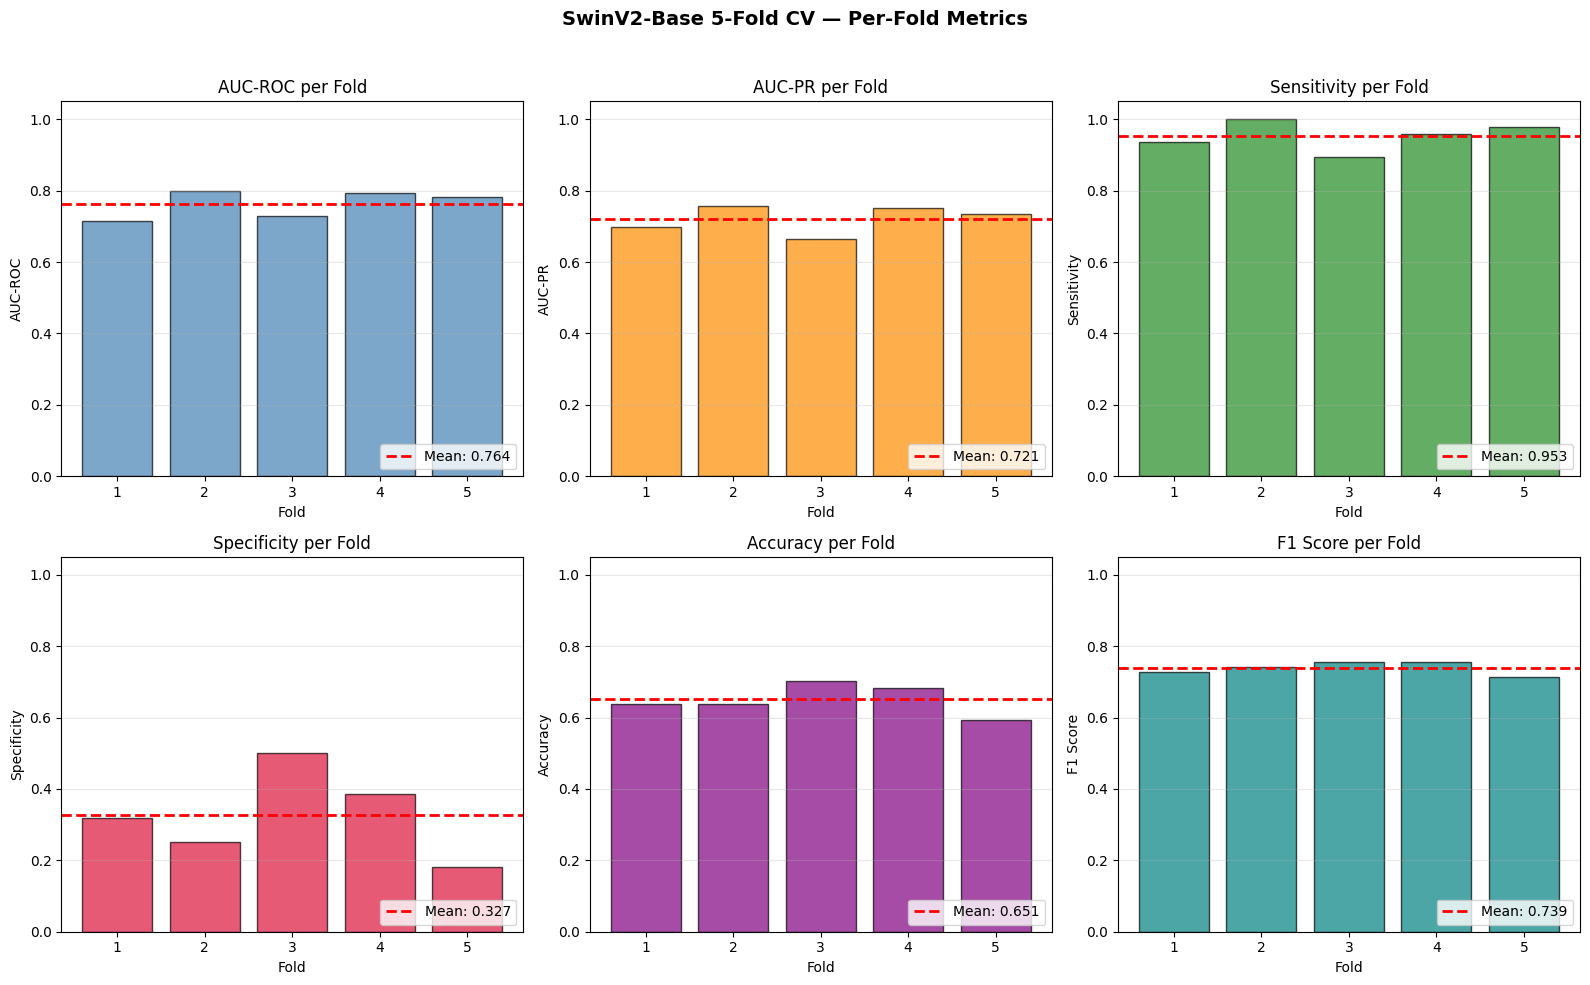

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("SwinV2-Base 5-Fold CV — Per-Fold Metrics", fontsize=14, fontweight='bold')

# Metrics to plot
metrics_to_plot = [
    ('auc_roc', 'AUC-ROC', 'steelblue'),
    ('auc_pr', 'AUC-PR', 'darkorange'),
    ('sensitivity', 'Sensitivity', 'forestgreen'),
    ('specificity', 'Specificity', 'crimson'),
    ('accuracy', 'Accuracy', 'purple'),
    ('f1', 'F1 Score', 'teal'),
]

for ax, (metric, label, color) in zip(axes.flatten(), metrics_to_plot):
    vals = df_test[metric].values
    folds = df_test['fold'].values
    ax.bar(folds, vals, color=color, alpha=0.7, edgecolor='black')
    ax.axhline(vals.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {vals.mean():.3f}')
    ax.set_xlabel('Fold')
    ax.set_ylabel(label)
    ax.set_title(f'{label} per Fold')
    ax.set_xticks(folds)
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

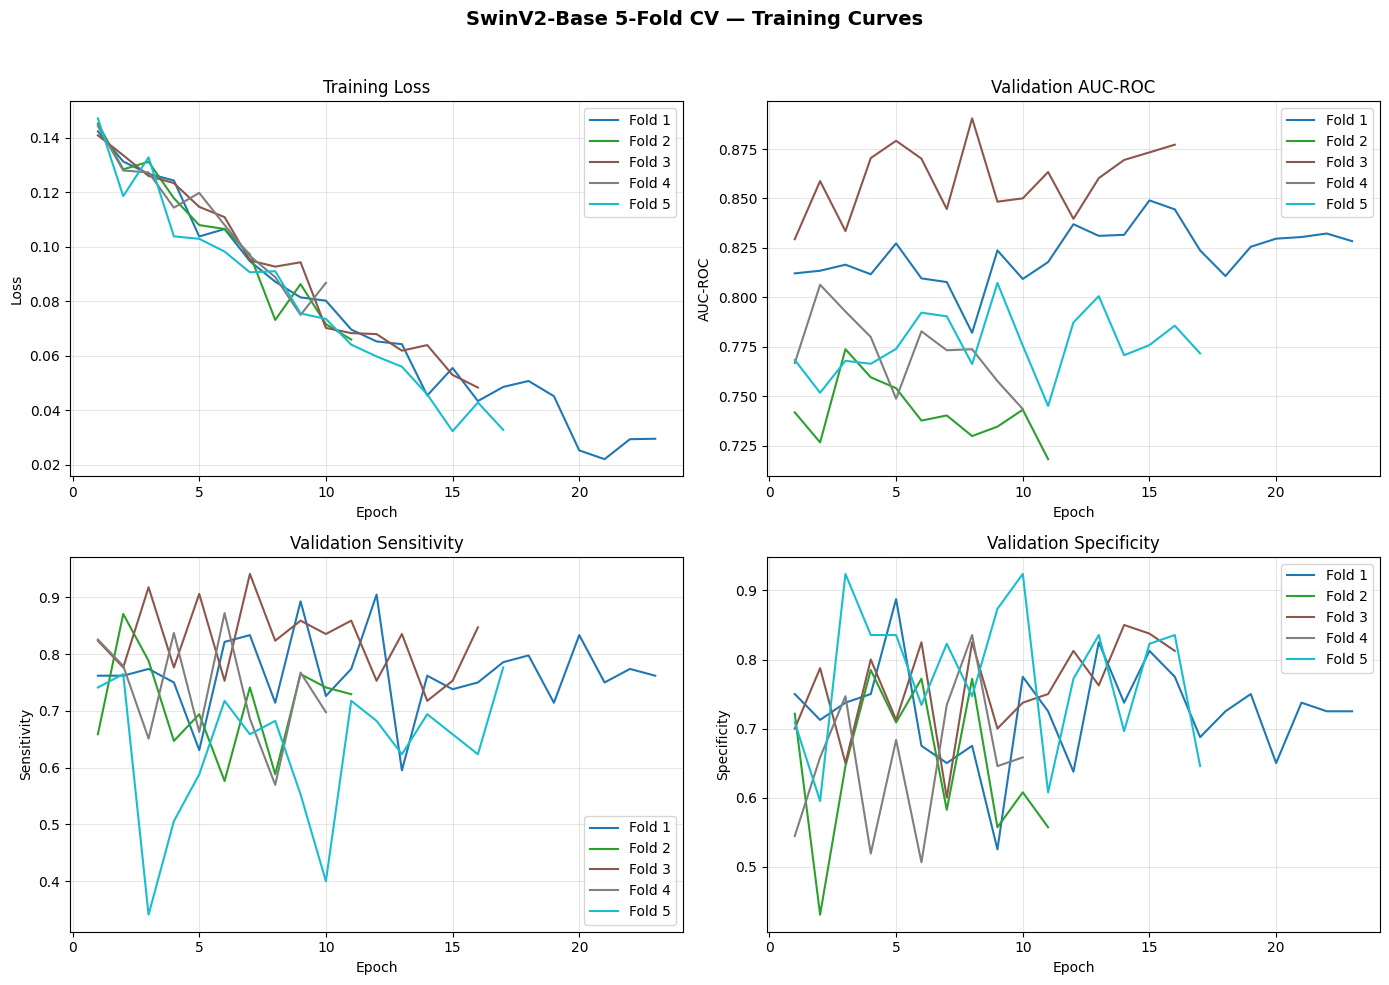

In [51]:
# Training curves for all folds
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SwinV2-Base 5-Fold CV — Training Curves', fontsize=14, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, K_FOLDS))

for fold_idx, history in enumerate(fold_histories):
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0, 0].plot(epochs, history['train_loss'], color=colors[fold_idx], label=f'Fold {fold_idx+1}')
    axes[0, 1].plot(epochs, history['val_auc'], color=colors[fold_idx], label=f'Fold {fold_idx+1}')
    axes[1, 0].plot(epochs, history['val_sens'], color=colors[fold_idx], label=f'Fold {fold_idx+1}')
    axes[1, 1].plot(epochs, history['val_spec'], color=colors[fold_idx], label=f'Fold {fold_idx+1}')

axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].set_title('Validation AUC-ROC')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC-ROC')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].set_title('Validation Sensitivity')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Sensitivity')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].set_title('Validation Specificity')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Specificity')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 9. Ensemble Evaluation (Averaged Probabilities)

In [52]:
# Ensemble: average probabilities from all folds
ensemble_probs = np.mean(fold_test_probs, axis=0)
ensemble_thresh, ensemble_sens, ensemble_spec = find_optimal_threshold(
    test_y_true, ensemble_probs, min_sensitivity=MIN_SENSITIVITY_TARGET
)

ensemble_metrics = compute_metrics(test_y_true, ensemble_probs, threshold=ensemble_thresh)

print("=" * 80)
print("  ENSEMBLE EVALUATION (Averaged Probabilities from 5 Folds)")
print("=" * 80)
print(f"\n  Optimal Threshold: {ensemble_thresh:.4f}")
print(f"  Accuracy:          {ensemble_metrics['accuracy']:.4f}")
print(f"  Sensitivity:       {ensemble_metrics['sensitivity']:.4f}")
print(f"  Specificity:       {ensemble_metrics['specificity']:.4f}")
print(f"  F1 Score:          {ensemble_metrics['f1']:.4f}")
print(f"  AUC-ROC:           {ensemble_metrics['auc_roc']:.4f}")
print("=" * 80)

  ENSEMBLE EVALUATION (Averaged Probabilities from 5 Folds)

  Optimal Threshold: 0.2300
  Accuracy:          0.7033
  Sensitivity:       0.9574
  Specificity:       0.4318
  F1 Score:          0.7692
  AUC-ROC:           0.7795


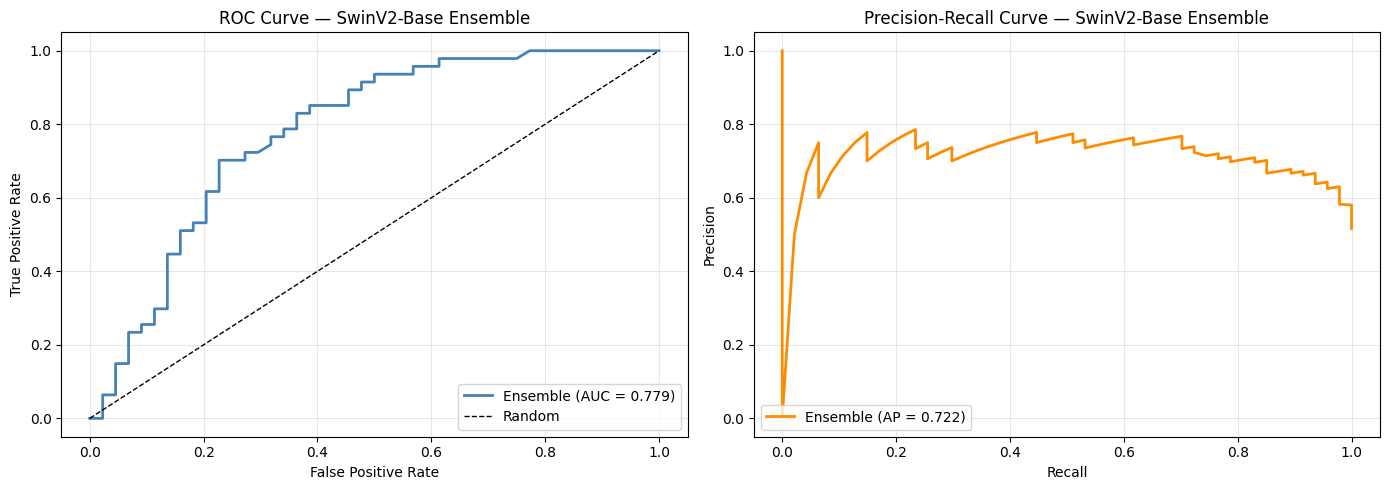

In [53]:
# ROC and PR curves for ensemble
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(test_y_true, ensemble_probs)
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Ensemble (AUC = {ensemble_metrics["auc_roc"]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — SwinV2-Base Ensemble')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# PR Curve
precision, recall, _ = precision_recall_curve(test_y_true, ensemble_probs)
auc_pr = average_precision_score(test_y_true, ensemble_probs)
axes[1].plot(recall, precision, color='darkorange', linewidth=2, label=f'Ensemble (AP = {auc_pr:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — SwinV2-Base Ensemble')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()